In [1]:
# ============================================================
# 03_Backtest.ipynb
# BTC/EUR Factor Strategy — Backtest & Performance Evaluation
# ============================================================
# This notebook implements and evaluates the factor-based
# trading strategy using the 2 macro factors selected in
# 02_Factor_Analysis.ipynb
#
# Strategy summary:
#   Factors  : us10y_5d (w=0.60) + vix_level (w=0.40)
#   Signal   : weighted z-score composite
#   Entry    : signal_score > 0.3 and VIX < 35
#   Exit     : signal_score < -0.3 or stop loss or take profit
#   Position : 30% of portfolio per trade
#   Stop loss: max(2x ATR, 5% hard stop)
#   Take profit: 3x ATR
#
# Backtest period: rolling 2-year window (dynamic)
# Factor selection snapshot: 2020-01-01 → 2026-06-05
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import requests
import os
from scipy import stats

plt.style.use("seaborn-v0_8-darkgrid")
os.makedirs("outputs", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Cell 2: Fetch data and build factors ─────────────────────

def fetch_btc_eur(start="2018-01-01"):
    df = yf.download("BTC-EUR", start=start, interval="1d",
                     auto_adjust=True, progress=False)
    df.columns    = df.columns.get_level_values(0)
    df.columns    = [c.lower() for c in df.columns]
    df.index.name = "date"
    df = df[["open", "high", "low", "close", "volume"]]
    df = df[df.index < pd.Timestamp.now().normalize()]
    return df

def fetch_macro(start="2018-01-01"):
    frames = []
    for ticker, name in [("^VIX","vix"), ("^TNX","us10y")]:
        d = yf.download(ticker, start=start, interval="1d",
                        auto_adjust=True, progress=False)
        d.columns    = d.columns.get_level_values(0)
        d.index.name = "date"
        d = d[["Close"]].rename(columns={"Close": name})
        frames.append(d)
    macro = frames[0].join(frames[1:], how="outer")
    macro = macro[macro.index < pd.Timestamp.now().normalize()]
    return macro

# Fetch
print("Fetching data...")
btc   = fetch_btc_eur()
macro = fetch_macro()

# Merge
df = btc.join(macro, how="left")
df[["vix","us10y"]] = df[["vix","us10y"]].ffill()
df = df.dropna()

# ── ATR ───────────────────────────────────────────────────────
tr = pd.concat([
    df["high"] - df["low"],
    abs(df["high"] - df["close"].shift(1)),
    abs(df["low"]  - df["close"].shift(1))
], axis=1).max(axis=1)
df["ATR"] = tr.rolling(14).mean()

# ── Factors ───────────────────────────────────────────────────
df["f_rates"] = -df["us10y"].diff(5)   # inverted: rising rates = negative
df["f_vix"]   =  df["vix"]

# ── Signal score (rolling z-score) ───────────────────────────
WEIGHTS = {"f_rates": 0.60, "f_vix": 0.40}
WINDOW  = 252

score = pd.Series(0.0, index=df.index)
for factor, weight in WEIGHTS.items():
    mean  = df[factor].rolling(WINDOW, min_periods=60).mean()
    std   = df[factor].rolling(WINDOW, min_periods=60).std()
    z     = (df[factor] - mean) / (std + 1e-10)
    z     = z.clip(-2, 2)
    score += z * weight
    df[f"{factor}_z"] = z

df["signal_score"] = score
df = df.dropna()

print(f"Dataset ready: {len(df)} rows")
print(f"Range        : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Signal range : {df['signal_score'].min():.3f} → {df['signal_score'].max():.3f}")

Fetching data...
Dataset ready: 3023 rows
Range        : 2018-03-07 → 2026-06-15
Signal range : -1.737 → 2.000


In [4]:
# ── Cell 3: Backtest engine ───────────────────────────────────

def run_backtest(df: pd.DataFrame,
                 buy_threshold:   float = 0.3,
                 sell_threshold:  float = -0.3,
                 sl_mult:         float = 2.0,
                 tp_mult:         float = 3.0,
                 position_pct:    float = 0.3,
                 initial_capital: float = 10000.0,
                 hard_stop_pct:   float = 0.05,
                 vix_threshold:   float = 35.0) -> tuple:
    """
    Event-driven backtest with fat-tail risk controls.

    Risk controls
    -------------
    - Hard stop loss  : max(ATR-based stop, 5% hard stop)
    - VIX filter      : no new entries when VIX > 35
    """
    capital     = initial_capital
    position    = 0.0
    entry_price = 0.0
    stop_loss   = 0.0
    take_profit = 0.0
    cooldown    = 0

    trades    = []
    portfolio = []

    df_bt = df.dropna(subset=["signal_score","ATR","vix"]).copy()

    for i in range(len(df_bt)):
        row   = df_bt.iloc[i]
        price = row["close"]
        atr   = row["ATR"]
        score = row["signal_score"]
        vix   = row["vix"]
        date  = df_bt.index[i]

        total_value = capital + position * price

        if cooldown > 0:
            cooldown -= 1

        # ── Stop loss / take profit ───────────────────────────
        if position > 0:
            if price <= stop_loss:
                proceeds = position * price
                pnl      = proceeds - (position * entry_price)
                pnl_pct  = (price / entry_price - 1) * 100
                capital  += proceeds
                trades.append({
                    "date": date, "action": "STOP_LOSS",
                    "price": price, "pnl": pnl, "pnl_pct": pnl_pct
                })
                position = 0.0
                cooldown = 2

            elif price >= take_profit:
                proceeds = position * price
                pnl      = proceeds - (position * entry_price)
                pnl_pct  = (price / entry_price - 1) * 100
                capital  += proceeds
                trades.append({
                    "date": date, "action": "TAKE_PROFIT",
                    "price": price, "pnl": pnl, "pnl_pct": pnl_pct
                })
                position = 0.0

        # ── Entry signal ──────────────────────────────────────
        vix_ok = vix < vix_threshold
        if score > buy_threshold and position == 0 \
                and cooldown == 0 and vix_ok:
            invest      = min(total_value * position_pct, capital)
            btc_buy     = invest / price
            position    = btc_buy
            entry_price = price
            capital    -= invest

            atr_stop    = price - sl_mult * atr
            hard_stop   = price * (1 - hard_stop_pct)
            stop_loss   = max(atr_stop, hard_stop)
            take_profit = price + tp_mult * atr

            trades.append({
                "date": date, "action": "BUY",
                "price": price, "size": position,
                "cost": invest, "sl": stop_loss,
                "tp": take_profit, "score": score, "vix": vix
            })

        elif score < sell_threshold and position > 0:
            proceeds = position * price
            pnl      = proceeds - (position * entry_price)
            pnl_pct  = (price / entry_price - 1) * 100
            capital  += proceeds
            trades.append({
                "date": date, "action": "SELL",
                "price": price, "pnl": pnl, "pnl_pct": pnl_pct
            })
            position = 0.0

        # ── Trailing stop ─────────────────────────────────────
        if position > 0 and price > entry_price:
            new_sl = price - sl_mult * atr
            if new_sl > stop_loss:
                stop_loss = new_sl

        portfolio.append(capital + position * price)

    return pd.DataFrame(trades), portfolio


def compute_metrics(trades_df, portfolio, initial_capital, df_bt):
    """Compute performance metrics."""
    final_value  = portfolio[-1]
    total_return = (final_value / initial_capital - 1) * 100
    bh_return    = (df_bt["close"].iloc[-1] /
                    df_bt["close"].iloc[0] - 1) * 100

    peak   = pd.Series(portfolio).cummax()
    dd     = (pd.Series(portfolio) - peak) / peak * 100
    max_dd = dd.min()

    daily_ret = pd.Series(portfolio).pct_change().dropna()
    sharpe    = (daily_ret.mean() / daily_ret.std()) * np.sqrt(365) \
                if daily_ret.std() > 0 else 0

    exit_trades = trades_df[
        trades_df["action"].isin(["SELL","STOP_LOSS","TAKE_PROFIT"])
    ]
    if len(exit_trades) > 0:
        wins          = exit_trades[exit_trades["pnl"] > 0]
        losses        = exit_trades[exit_trades["pnl"] <= 0]
        win_rate      = len(wins) / len(exit_trades) * 100
        avg_win       = wins["pnl_pct"].mean()   if len(wins)   > 0 else 0
        avg_loss      = losses["pnl_pct"].mean() if len(losses) > 0 else 0
        gross_win     = wins["pnl"].sum()
        gross_loss    = abs(losses["pnl"].sum())
        profit_factor = gross_win / gross_loss   if gross_loss  > 0 else float("inf")
    else:
        win_rate = avg_win = avg_loss = profit_factor = 0

    return {
        "final_value"   : final_value,
        "total_return"  : total_return,
        "bh_return"     : bh_return,
        "alpha"         : total_return - bh_return,
        "total_trades"  : len(exit_trades),
        "win_rate"      : win_rate,
        "avg_win"       : avg_win,
        "avg_loss"      : avg_loss,
        "profit_factor" : profit_factor,
        "max_drawdown"  : max_dd,
        "sharpe"        : sharpe,
    }

print("Backtest engine ready.")

Backtest engine ready.


In [5]:
# ── Cell 4: Run backtest ──────────────────────────────────────

# Dynamic 2-year backtest window
two_years_ago = pd.Timestamp.now().normalize() - pd.DateOffset(years=2)
df_bt         = df[df.index >= two_years_ago].copy()

print(f"Backtest period : {df_bt.index[0].date()} → {df_bt.index[-1].date()}")
print(f"Rows            : {len(df_bt)}")

# Run
trades_df, portfolio = run_backtest(df_bt, initial_capital=10000.0)
metrics = compute_metrics(trades_df, portfolio, 10000.0, df_bt)

# Print report
print("\n" + "="*55)
print("  BTC/EUR Factor Strategy — Backtest Report")
print("="*55)
print(f"  Backtest period   : {df_bt.index[0].date()} → {df_bt.index[-1].date()}")
print(f"  Initial capital   : EUR {10000.0:>10,.2f}")
print(f"  Final value       : EUR {metrics['final_value']:>10,.2f}")
print(f"  Strategy return   : {metrics['total_return']:>+10.2f}%")
print(f"  Buy & hold return : {metrics['bh_return']:>+10.2f}%")
print(f"  Alpha             : {metrics['alpha']:>+10.2f}%")
print(f"  ---")
print(f"  Total trades      : {metrics['total_trades']:>10d}")
print(f"  Win rate          : {metrics['win_rate']:>10.1f}%")
print(f"  Avg win           : {metrics['avg_win']:>+10.2f}%")
print(f"  Avg loss          : {metrics['avg_loss']:>+10.2f}%")
print(f"  Profit factor     : {metrics['profit_factor']:>10.2f}")
print(f"  Max drawdown      : {metrics['max_drawdown']:>10.2f}%")
print(f"  Sharpe ratio      : {metrics['sharpe']:>10.2f}")
print("="*55)

Backtest period : 2024-06-16 → 2026-06-15
Rows            : 730

  BTC/EUR Factor Strategy — Backtest Report
  Backtest period   : 2024-06-16 → 2026-06-15
  Initial capital   : EUR  10,000.00
  Final value       : EUR  11,481.51
  Strategy return   :     +14.82%
  Buy & hold return :      -8.15%
  Alpha             :     +22.97%
  ---
  Total trades      :         47
  Win rate          :       53.2%
  Avg win           :      +6.40%
  Avg loss          :      -5.35%
  Profit factor     :       1.32
  Max drawdown      :      -7.61%
  Sharpe ratio      :       0.75


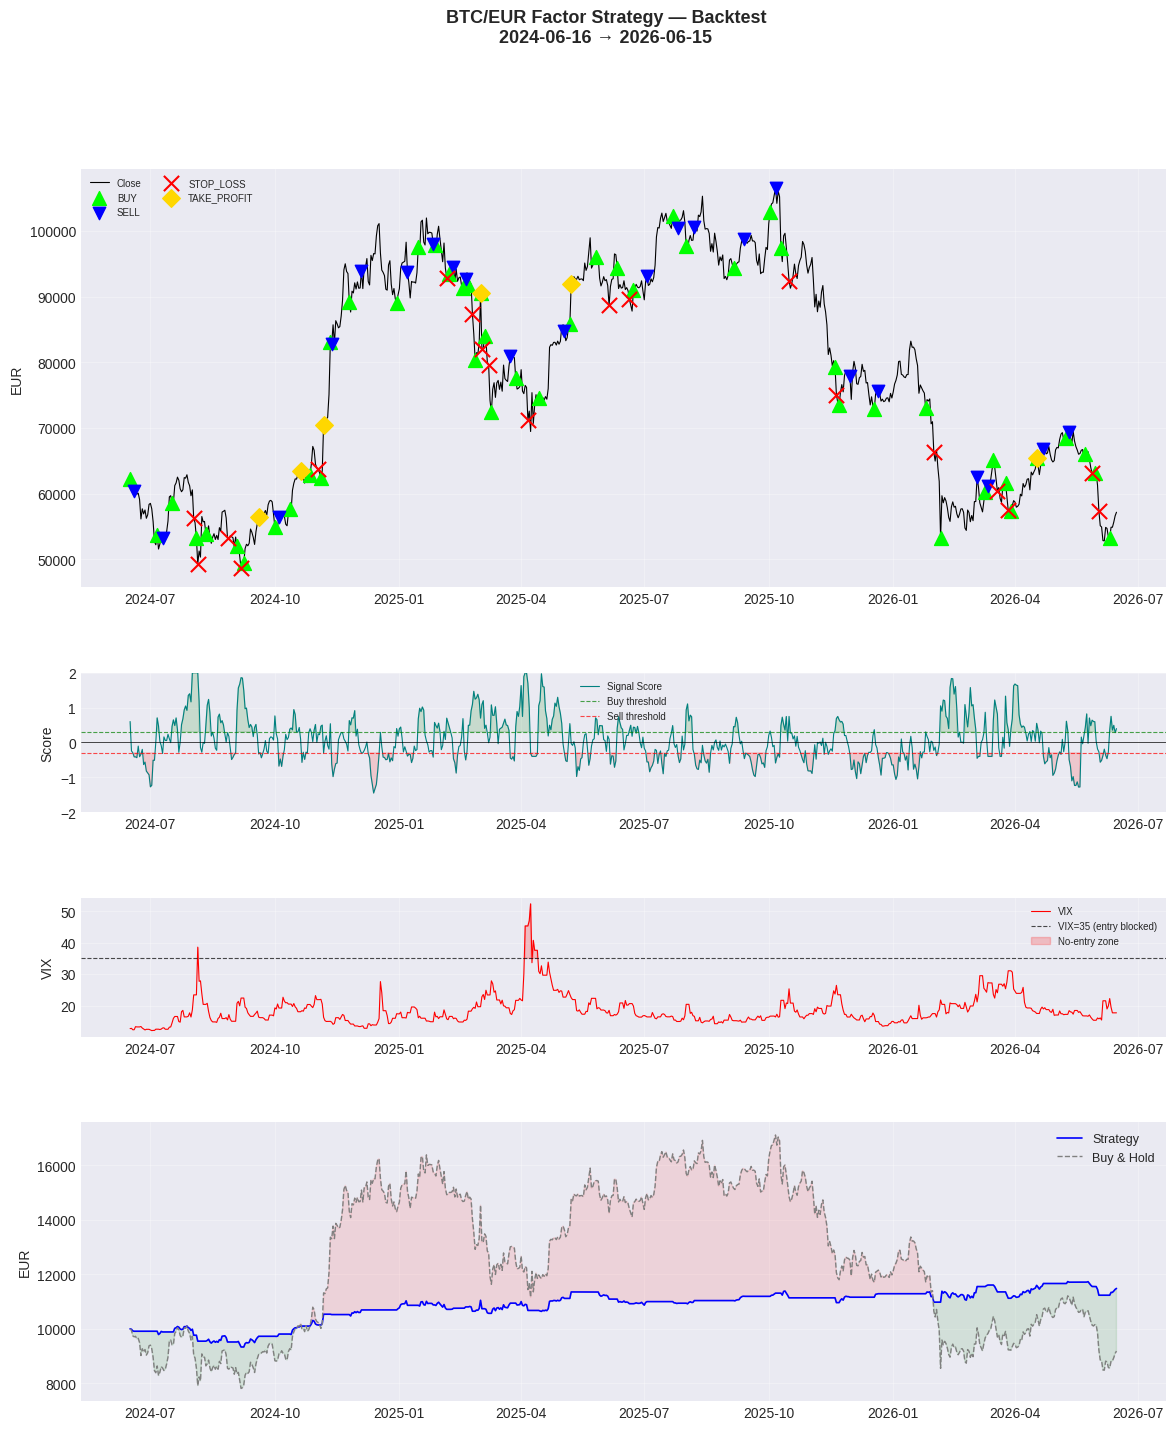

In [6]:
# ── Cell 5: Backtest visualisation ───────────────────────────

df_bt["portfolio"] = portfolio

fig = plt.figure(figsize=(14, 16))
fig.suptitle(
    f"BTC/EUR Factor Strategy — Backtest\n"
    f"{df_bt.index[0].date()} → {df_bt.index[-1].date()}",
    fontsize=13, fontweight="bold"
)

gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 2], hspace=0.35)

# ── Price + trades ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.plot(df_bt.index, df_bt["close"], color="black", lw=0.8, label="Close")

for action, marker, color, size in [
    ("BUY",         "^", "lime",  100),
    ("SELL",        "v", "blue",   80),
    ("STOP_LOSS",   "x", "red",   120),
    ("TAKE_PROFIT", "D", "gold",   80),
]:
    t = trades_df[trades_df["action"] == action]
    if len(t) > 0:
        ax0.scatter(t["date"], t["price"], marker=marker,
                    color=color, s=size, zorder=5, label=action)

ax0.set_ylabel("EUR")
ax0.legend(loc="upper left", fontsize=7, ncol=2)
ax0.grid(True, alpha=0.3)

# ── Signal score ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
ax1.plot(df_bt.index, df_bt["signal_score"],
         color="teal", lw=0.8, label="Signal Score")
ax1.axhline( 0.3, color="green", ls="--", lw=0.8,
             alpha=0.7, label="Buy threshold")
ax1.axhline(-0.3, color="red",   ls="--", lw=0.8,
             alpha=0.7, label="Sell threshold")
ax1.axhline(0,    color="black", lw=0.5)
ax1.fill_between(df_bt.index, df_bt["signal_score"], 0.3,
                 where=df_bt["signal_score"] > 0.3,
                 alpha=0.15, color="green")
ax1.fill_between(df_bt.index, df_bt["signal_score"], -0.3,
                 where=df_bt["signal_score"] < -0.3,
                 alpha=0.15, color="red")
ax1.set_ylabel("Score")
ax1.set_ylim(-2, 2)
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# ── VIX ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
ax2.plot(df_bt.index, df_bt["vix"], color="red", lw=0.8, label="VIX")
ax2.axhline(35, color="black", ls="--", lw=0.8,
            alpha=0.7, label="VIX=35 (entry blocked)")
ax2.fill_between(df_bt.index, df_bt["vix"], 35,
                 where=df_bt["vix"] > 35,
                 alpha=0.2, color="red", label="No-entry zone")
ax2.set_ylabel("VIX")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# ── Portfolio vs Buy & Hold ───────────────────────────────────
ax3 = fig.add_subplot(gs[3])
bh_line = 10000.0 * df_bt["close"] / df_bt["close"].iloc[0]
ax3.plot(df_bt.index, df_bt["portfolio"],
         color="blue", lw=1.2, label="Strategy")
ax3.plot(df_bt.index, bh_line,
         color="gray", lw=1, ls="--", label="Buy & Hold")
ax3.fill_between(df_bt.index, df_bt["portfolio"], bh_line,
                 where=df_bt["portfolio"] >= bh_line,
                 alpha=0.1, color="green")
ax3.fill_between(df_bt.index, df_bt["portfolio"], bh_line,
                 where=df_bt["portfolio"] < bh_line,
                 alpha=0.1, color="red")
ax3.set_ylabel("EUR")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.savefig("outputs/08_backtest.png", dpi=150, bbox_inches="tight")
plt.show()

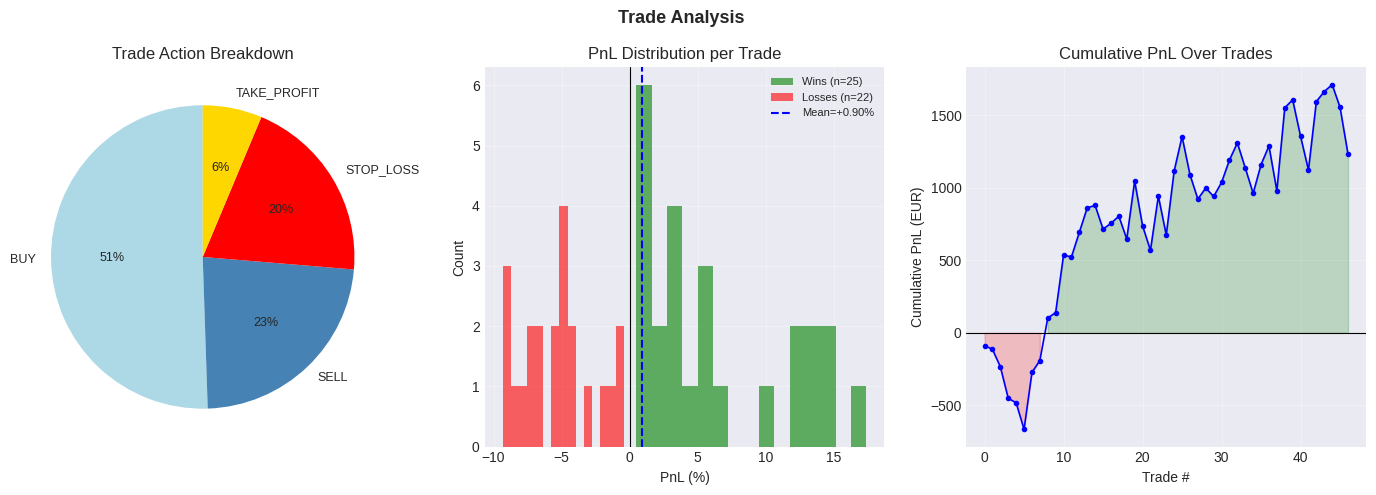

Total exit trades : 47
  TAKE_PROFIT     : 6
  SELL (signal)   : 22
  STOP_LOSS       : 19
Avg hold period   : 16 days per trade


In [7]:
# ── Cell 6: Trade analysis ────────────────────────────────────

exit_trades = trades_df[
    trades_df["action"].isin(["SELL","STOP_LOSS","TAKE_PROFIT"])
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Trade Analysis", fontsize=13, fontweight="bold")

# ── Win/Loss breakdown ────────────────────────────────────────
ax = axes[0]
action_counts = trades_df["action"].value_counts()
colors_pie    = {
    "BUY"         : "lightblue",
    "SELL"        : "steelblue",
    "STOP_LOSS"   : "red",
    "TAKE_PROFIT" : "gold",
}
pie_colors = [colors_pie.get(a, "gray") for a in action_counts.index]
ax.pie(action_counts.values, labels=action_counts.index,
       colors=pie_colors, autopct="%1.0f%%",
       startangle=90, textprops={"fontsize": 9})
ax.set_title("Trade Action Breakdown")

# ── PnL distribution ──────────────────────────────────────────
ax = axes[1]
wins   = exit_trades[exit_trades["pnl"] > 0]["pnl_pct"]
losses = exit_trades[exit_trades["pnl"] <= 0]["pnl_pct"]
ax.hist(wins,   bins=15, color="green", alpha=0.6, label=f"Wins (n={len(wins)})")
ax.hist(losses, bins=15, color="red",   alpha=0.6, label=f"Losses (n={len(losses)})")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(exit_trades["pnl_pct"].mean(), color="blue",
           lw=1.5, ls="--",
           label=f"Mean={exit_trades['pnl_pct'].mean():+.2f}%")
ax.set_xlabel("PnL (%)")
ax.set_ylabel("Count")
ax.set_title("PnL Distribution per Trade")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Cumulative PnL ────────────────────────────────────────────
ax = axes[2]
cum_pnl = exit_trades["pnl"].cumsum()
ax.plot(range(len(cum_pnl)), cum_pnl.values,
        color="blue", lw=1.2, marker="o", markersize=3)
ax.axhline(0, color="black", lw=0.8)
ax.fill_between(range(len(cum_pnl)), cum_pnl.values, 0,
                where=cum_pnl.values >= 0, alpha=0.2, color="green")
ax.fill_between(range(len(cum_pnl)), cum_pnl.values, 0,
                where=cum_pnl.values < 0,  alpha=0.2, color="red")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative PnL (EUR)")
ax.set_title("Cumulative PnL Over Trades")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/09_trade_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Trade summary
print(f"Total exit trades : {len(exit_trades)}")
print(f"  TAKE_PROFIT     : {len(trades_df[trades_df['action']=='TAKE_PROFIT'])}")
print(f"  SELL (signal)   : {len(trades_df[trades_df['action']=='SELL'])}")
print(f"  STOP_LOSS       : {len(trades_df[trades_df['action']=='STOP_LOSS'])}")
print(f"Avg hold period   : {len(df_bt) / len(exit_trades):.0f} days per trade")

In [8]:
# ── Cell 7: Strategy summary ──────────────────────────────────

today         = pd.Timestamp.now().normalize()
bt_start      = df_bt.index[0].date()
bt_end        = df_bt.index[-1].date()
latest        = df_bt.iloc[-1]
latest_signal = "BUY" if latest["signal_score"] > 0.3 \
                else "SELL" if latest["signal_score"] < -0.3 \
                else "HOLD"

print("=" * 60)
print("  Strategy Summary")
print("=" * 60)
print(f"""
STRATEGY DESIGN
  Factors    : us10y_5d (w=0.60) + vix_level (w=0.40)
  Entry      : signal_score > 0.3 AND VIX < 35
  Exit       : signal_score < -0.3 OR stop loss OR take profit
  Stop loss  : max(2x ATR, 5% hard stop)
  Take profit: 3x ATR (trailing)
  Position   : 30% of portfolio per trade
  Capital    : EUR 10,000

BACKTEST RESULTS ({bt_start} → {bt_end})
  Strategy return   : {metrics['total_return']:>+.2f}%
  Buy & hold return : {metrics['bh_return']:>+.2f}%
  Alpha             : {metrics['alpha']:>+.2f}%
  Sharpe ratio      : {metrics['sharpe']:.2f}
  Max drawdown      : {metrics['max_drawdown']:.2f}%
  Win rate          : {metrics['win_rate']:.1f}%
  Profit factor     : {metrics['profit_factor']:.2f}
  Total trades      : {metrics['total_trades']}

RISK CONTROLS (motivated by fat-tail analysis in 01_EDA.ipynb)
  BTC kurtosis = 9.39 (vs normal = 3)
  → Hard stop loss added: max 5% loss per trade
  → VIX filter added: no entry when VIX > 35

LIMITATIONS
  - Factor selection uses overlapping data with backtest period
    (minor look-ahead bias, documented in 02_Factor_Analysis.ipynb)
  - Only 2 years of backtest data (730 days)
  - No transaction costs modelled (Revolut has 0% crypto fees)
  - Past performance does not guarantee future results

TODAY'S SIGNAL (as of {today.date()})
  BTC/EUR close    : EUR {latest['close']:,.2f}
  US 10Y yield     : {latest['us10y']:.3f}%
  VIX              : {latest['vix']:.1f}
  Signal score     : {latest['signal_score']:.3f}
  Signal           : {latest_signal}
""")

if latest_signal == "BUY":
    sl = latest["close"] - 2.0 * latest["ATR"]
    tp = latest["close"] + 3.0 * latest["ATR"]
    hard_sl = latest["close"] * 0.95
    actual_sl = max(sl, hard_sl)
    invest = 10000 * 0.30
    print(f"  Invest (30%)     : EUR {invest:,.0f}")
    print(f"  Stop loss        : EUR {actual_sl:,.2f} "
          f"({(actual_sl/latest['close']-1)*100:+.1f}%)")
    print(f"  Take profit      : EUR {tp:,.2f} "
          f"({(tp/latest['close']-1)*100:+.1f}%)")

print("=" * 60)

  Strategy Summary

STRATEGY DESIGN
  Factors    : us10y_5d (w=0.60) + vix_level (w=0.40)
  Entry      : signal_score > 0.3 AND VIX < 35
  Exit       : signal_score < -0.3 OR stop loss OR take profit
  Stop loss  : max(2x ATR, 5% hard stop)
  Take profit: 3x ATR (trailing)
  Position   : 30% of portfolio per trade
  Capital    : EUR 10,000

BACKTEST RESULTS (2024-06-16 → 2026-06-15)
  Strategy return   : +14.82%
  Buy & hold return : -8.15%
  Alpha             : +22.97%
  Sharpe ratio      : 0.75
  Max drawdown      : -7.61%
  Win rate          : 53.2%
  Profit factor     : 1.32
  Total trades      : 47

RISK CONTROLS (motivated by fat-tail analysis in 01_EDA.ipynb)
  BTC kurtosis = 9.39 (vs normal = 3)
  → Hard stop loss added: max 5% loss per trade
  → VIX filter added: no entry when VIX > 35

LIMITATIONS
  - Factor selection uses overlapping data with backtest period
    (minor look-ahead bias, documented in 02_Factor_Analysis.ipynb)
  - Only 2 years of backtest data (730 days)
  - 